# Pokémon Analytics

Exploratory analysis over the dbt mart tables built from `PokemonData.csv`.

**Database:** `../dbt/data_stack.duckdb`  
**Marts available:**
- `main_marts.mart_pokemon_by_type` — avg stats per primary type
- `main_marts.mart_pokemon_by_generation` — stat trends across generations
- `main_marts.mart_legendary_comparison` — legendary vs non-legendary breakdown

Run `dbt run --profiles-dir .` from the `dbt/` directory before using this notebook.

In [13]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.1f}".format)

DB_PATH = "../dbt/data_stack.duckdb"
con = duckdb.connect(DB_PATH, read_only=True)

def q(sql: str) -> pd.DataFrame:
    return con.execute(sql).df()

print("Connected to", DB_PATH)

Connected to ../dbt/data_stack.duckdb


In [14]:
# Filter settings — applied to all sections below
GENERATIONS = (1, 2)
EXCLUDE_MEGA = True

_gen_filter  = f"generation in {GENERATIONS}"
_mega_filter = "is_mega = false" if EXCLUDE_MEGA else "1=1"
BASE_FILTER  = f"{_gen_filter} and {_mega_filter}"

print(f"Active filter: {BASE_FILTER}")

Active filter: generation in (1, 2) and is_mega = false


## 1. Raw data preview

A quick look at the cleaned staging layer before aggregation.

In [15]:
pokemon = q(f"select * from main_intermediate.int_pokemon_stats where {BASE_FILTER} order by base_stat_total desc")
print(f"{len(pokemon)} rows")
pokemon.head(10)

251 rows


,pokemon_id,pokemon_name,primary_type,secondary_type,hp,attack,defense,special_attack,special_defense,speed,generation,is_legendary,base_stat_total,total_offense,total_defense,is_dual_type,is_mega
0,250,Ho-oh,Fire,Flying,106,130,90,110,154,90,2,True,680,240,244,True,False
1,249,Lugia,Psychic,Flying,106,90,130,90,154,110,2,True,680,180,284,True,False
2,150,Mewtwo,Psychic,None,106,110,90,154,90,130,1,True,680,264,180,False,False
3,251,Celebi,Psychic,Grass,100,100,100,100,100,100,2,False,600,200,200,True,False
4,248,Tyranitar,Rock,Dark,100,134,110,95,100,61,2,False,600,229,210,True,False
5,151,Mew,Psychic,None,100,100,100,100,100,100,1,False,600,200,200,False,False
6,149,Dragonite,Dragon,Flying,91,134,95,100,100,80,1,False,600,234,195,True,False
7,145,Zapdos,Electric,Flying,90,90,85,125,90,100,1,True,580,215,175,True,False
8,245,Suicune,Water,None,100,75,115,90,115,85,2,True,580,165,230,False,False
9,244,Entei,Fire,None,115,115,85,90,75,100,2,True,580,205,160,False,False


## 2. Stats by primary type

Which types have the strongest average base stat totals?

In [16]:
by_type = q(f"""
select
    primary_type,
    count(*)                                                as pokemon_count,
    sum(case when is_legendary then 1 else 0 end)          as legendary_count,
    round(avg(base_stat_total), 1)                         as avg_base_stat_total,
    max(base_stat_total)                                    as max_base_stat_total,
    round(avg(hp), 1)                                      as avg_hp,
    round(avg(attack), 1)                                   as avg_attack,
    round(avg(defense), 1)                                  as avg_defense,
    round(avg(special_attack), 1)                          as avg_special_attack,
    round(avg(special_defense), 1)                         as avg_special_defense,
    round(avg(speed), 1)                                    as avg_speed
from main_intermediate.int_pokemon_stats
where {BASE_FILTER}
group by primary_type
order by avg_base_stat_total desc
""")
by_type

,primary_type,pokemon_count,legendary_count,avg_base_stat_total,max_base_stat_total,avg_hp,avg_attack,avg_defense,avg_special_attack,avg_special_defense,avg_speed
0,Steel,2,0.0,487.5,510,70.0,82.5,170.0,47.5,67.5,50.0
1,Psychic,15,2.0,473.1,680,75.0,64.4,64.7,94.7,87.0,87.3
2,Fire,20,3.0,450.0,680,64.9,80.9,65.1,84.2,76.2,78.8
3,Dragon,3,0.0,440.0,600,64.3,94.0,68.3,73.3,73.3,66.7
4,Dark,5,0.0,438.0,525,66.0,79.0,57.4,74.0,75.4,86.2
5,Rock,13,0.0,423.5,600,59.6,86.3,102.7,60.0,60.4,54.5
6,Electric,15,2.0,420.0,580,57.3,61.1,59.3,86.3,69.7,86.3
7,Water,46,1.0,413.7,580,69.2,69.4,75.5,66.2,69.9,63.5
8,Ghost,4,0.0,412.5,500,48.8,52.5,48.8,107.5,62.5,92.5
9,Grass,21,0.0,395.5,525,62.4,64.8,67.6,76.7,68.8,55.2


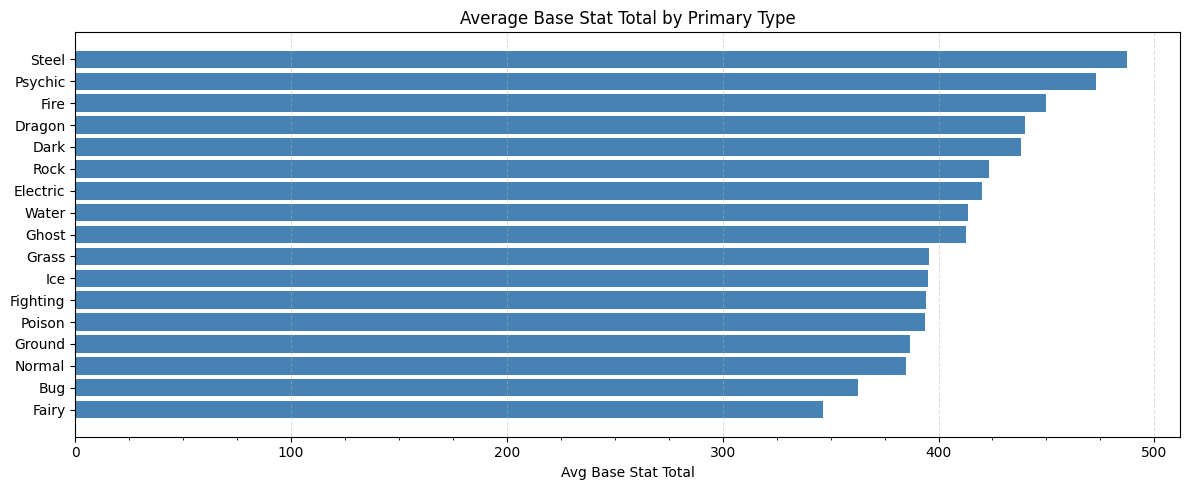

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.barh(by_type["primary_type"], by_type["avg_base_stat_total"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Avg Base Stat Total")
ax.set_title("Average Base Stat Total by Primary Type")
ax.xaxis.set_minor_locator(ticker.MultipleLocator(25))
ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 3. Stat profile by type

How do offensive vs defensive stat profiles differ across types?

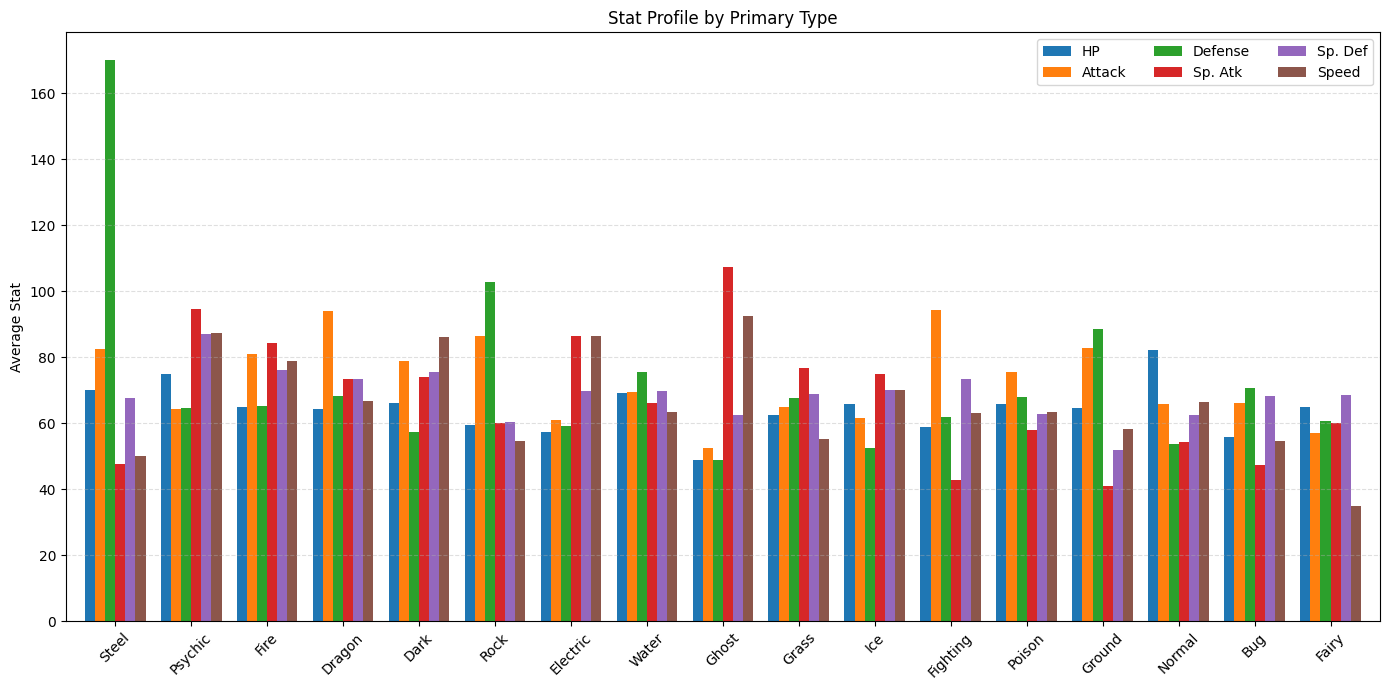

In [18]:
stats = ["avg_hp", "avg_attack", "avg_defense", "avg_special_attack", "avg_special_defense", "avg_speed"]
labels = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

plot_df = by_type.set_index("primary_type")[stats]
plot_df.columns = labels

fig, ax = plt.subplots(figsize=(14, 7))
plot_df.plot(kind="bar", ax=ax, width=0.8)
ax.set_xlabel("")
ax.set_ylabel("Average Stat")
ax.set_title("Stat Profile by Primary Type")
ax.legend(loc="upper right", ncol=3)
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 4. Trends across generations

Did Pokémon get stronger over time? How did legendary density change?

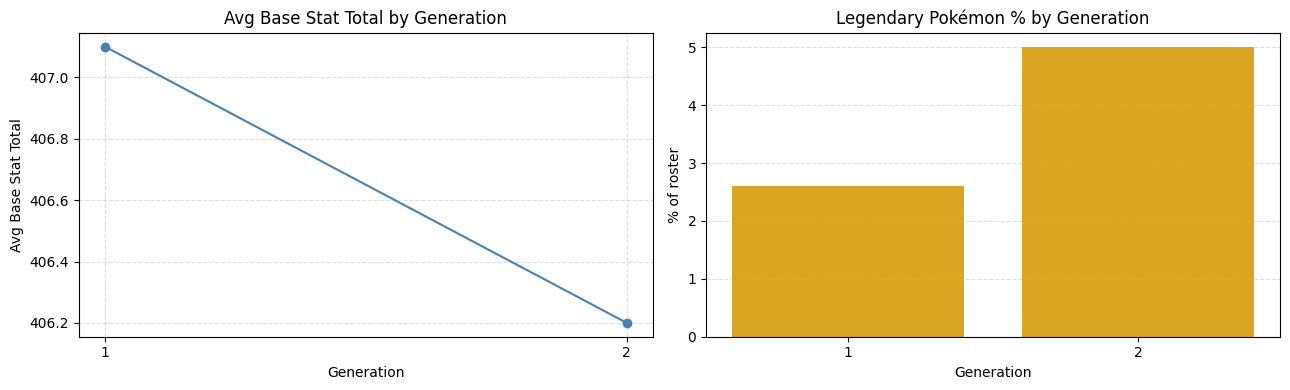

,generation,pokemon_count,legendary_count,legendary_pct,avg_base_stat_total,max_base_stat_total,avg_total_offense,avg_total_defense,avg_speed
0,1,151,4.0,2.6,407.1,680,139.7,134.2,68.9
1,2,100,5.0,5.0,406.2,680,132.6,141.6,61.4


In [19]:
by_gen = q(f"""
select
    generation,
    count(*)                                                        as pokemon_count,
    sum(case when is_legendary then 1 else 0 end)                  as legendary_count,
    round(
        100.0 * sum(case when is_legendary then 1 else 0 end)
        / count(*), 1
    )                                                               as legendary_pct,
    round(avg(base_stat_total), 1)                                  as avg_base_stat_total,
    max(base_stat_total)                                            as max_base_stat_total,
    round(avg(total_offense), 1)                                    as avg_total_offense,
    round(avg(total_defense), 1)                                    as avg_total_defense,
    round(avg(speed), 1)                                            as avg_speed
from main_intermediate.int_pokemon_stats
where {BASE_FILTER}
group by generation
order by generation
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(by_gen["generation"], by_gen["avg_base_stat_total"], marker="o", color="steelblue")
axes[0].set_title("Avg Base Stat Total by Generation")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Avg Base Stat Total")
axes[0].set_xticks(by_gen["generation"])
axes[0].grid(linestyle="--", alpha=0.4)

axes[1].bar(by_gen["generation"], by_gen["legendary_pct"], color="goldenrod")
axes[1].set_title("Legendary Pokémon % by Generation")
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("% of roster")
axes[1].set_xticks(by_gen["generation"])
axes[1].grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

by_gen

## 5. Legendary vs non-legendary

How much stronger are legendaries across every stat?

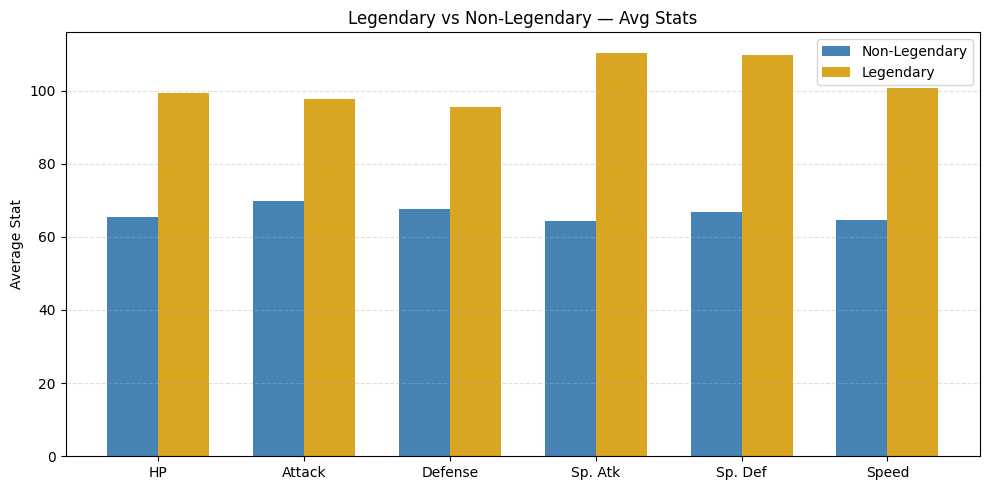

,is_legendary,pokemon_count,avg_base_stat_total,avg_hp,avg_attack,avg_defense,avg_special_attack,avg_special_defense,avg_speed,avg_total_offense,avg_total_defense
0,False,242,399.0,65.5,69.8,67.7,64.4,66.9,64.6,134.2,134.7
1,True,9,613.3,99.2,97.8,95.6,110.4,109.8,100.6,208.2,205.3


In [20]:
leg = q(f"""
select
    is_legendary,
    count(*)                            as pokemon_count,
    round(avg(base_stat_total), 1)      as avg_base_stat_total,
    round(avg(hp), 1)                   as avg_hp,
    round(avg(attack), 1)               as avg_attack,
    round(avg(defense), 1)              as avg_defense,
    round(avg(special_attack), 1)       as avg_special_attack,
    round(avg(special_defense), 1)      as avg_special_defense,
    round(avg(speed), 1)                as avg_speed,
    round(avg(total_offense), 1)        as avg_total_offense,
    round(avg(total_defense), 1)        as avg_total_defense
from main_intermediate.int_pokemon_stats
where {BASE_FILTER}
group by is_legendary
""")

stat_cols = ["avg_hp", "avg_attack", "avg_defense", "avg_special_attack", "avg_special_defense", "avg_speed"]
stat_labels = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

legendary_vals    = leg.loc[leg["is_legendary"] == True,  stat_cols].values[0]
nonlegendary_vals = leg.loc[leg["is_legendary"] == False, stat_cols].values[0]

x = range(len(stat_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - width/2 for i in x], nonlegendary_vals, width, label="Non-Legendary", color="steelblue")
ax.bar([i + width/2 for i in x], legendary_vals,    width, label="Legendary",     color="goldenrod")

ax.set_xticks(list(x))
ax.set_xticklabels(stat_labels)
ax.set_ylabel("Average Stat")
ax.set_title("Legendary vs Non-Legendary — Avg Stats")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

leg

## 6. Ad-hoc queries

Use this cell to write your own queries against any layer.

## 7. Mega Pokémon

In [21]:
q("""
select
    pokemon_name,
    primary_type,
    secondary_type,
    hp,
    attack,
    defense,
    special_attack,
    special_defense,
    speed,
    base_stat_total
from main_intermediate.int_pokemon_stats
where is_mega = true
order by base_stat_total desc
""")

,pokemon_name,primary_type,secondary_type,hp,attack,defense,special_attack,special_defense,speed,base_stat_total
0,RayquazaMega Rayquaza,Dragon,Flying,105,180,100,180,100,115,780
1,MewtwoMega Mewtwo X,Psychic,Fighting,106,190,100,154,100,130,780
2,MewtwoMega Mewtwo Y,Psychic,None,106,150,70,194,120,140,780
3,GarchompMega Garchomp,Dragon,Ground,108,170,115,120,95,92,700
4,LatiosMega Latios,Dragon,Psychic,80,130,100,160,120,110,700
5,LatiasMega Latias,Dragon,Psychic,80,100,120,140,150,110,700
6,MetagrossMega Metagross,Steel,Psychic,80,145,150,105,110,110,700
7,SalamenceMega Salamence,Dragon,Flying,95,145,130,120,90,120,700
8,DiancieMega Diancie,Rock,Fairy,50,160,110,160,110,110,700
9,TyranitarMega Tyranitar,Rock,Dark,100,164,150,95,120,71,700


## 8. Best in type — Legendary vs Non-Legendary

Highest base stat total per primary type, split by legendary status.

In [22]:
best_in_type = q(f"""
with ranked as (
    select
        primary_type,
        is_legendary,
        pokemon_name,
        secondary_type,
        base_stat_total,
        row_number() over (
            partition by primary_type, is_legendary
            order by base_stat_total desc
        ) as rn
    from main_intermediate.int_pokemon_stats
    where {BASE_FILTER}
)
select
    primary_type,
    is_legendary,
    pokemon_name,
    secondary_type,
    base_stat_total
from ranked
where rn <= 3
order by is_legendary, primary_type, base_stat_total desc
""")

print("Non-Legendary")
display(best_in_type[best_in_type["is_legendary"] == False].drop(columns="is_legendary").reset_index(drop=True))

print("\nLegendary")
display(best_in_type[best_in_type["is_legendary"] == True].drop(columns="is_legendary").reset_index(drop=True))

Non-Legendary


,primary_type,pokemon_name,secondary_type,base_stat_total
0,Bug,Shuckle,Rock,505
1,Bug,Scyther,Flying,500
2,Bug,Scizor,Steel,500
3,Dark,Umbreon,None,525
4,Dark,Houndoom,Fire,500
5,Dark,Sneasel,Ice,430
6,Dragon,Dragonite,Flying,600
7,Dragon,Dragonair,None,420
8,Dragon,Dratini,None,300
9,Electric,Jolteon,None,525



Legendary


,primary_type,pokemon_name,secondary_type,base_stat_total
0,Electric,Raikou,None,580
1,Electric,Zapdos,Flying,580
2,Fire,Ho-oh,Flying,680
3,Fire,Entei,None,580
4,Fire,Moltres,Flying,580
5,Ice,Articuno,Flying,580
6,Psychic,Lugia,Flying,680
7,Psychic,Mewtwo,None,680
8,Water,Suicune,None,580


## 9. My team — gap to optimal

Enter your current team below, then run the cell to see how each Pokémon compares to the highest base stat total available for its primary type (Gen 1 & 2, non-legendary).

In [28]:
# Enter your team here — names must match exactly as they appear in the data
MY_TEAM = [
    "Typhlosion",
    "Lapras",
    "Lugia",
    "Victreebel",
    "Steelix",
    "Ampharos",
    "Scizor"
]

,your_pokemon,primary_type,secondary_type,your_bst,best_pokemon,best_bst,gap
0,Typhlosion,Fire,None,534,Ho-oh,680,146
1,Ampharos,Electric,None,510,Zapdos,580,70
2,Lapras,Water,Ice,535,Suicune,580,45
3,Victreebel,Grass,Poison,490,Venusaur,525,35
4,Scizor,Bug,Steel,500,Shuckle,505,5
5,Steelix,Steel,Ground,510,Steelix,510,0
6,Lugia,Psychic,Flying,680,Mewtwo,680,0


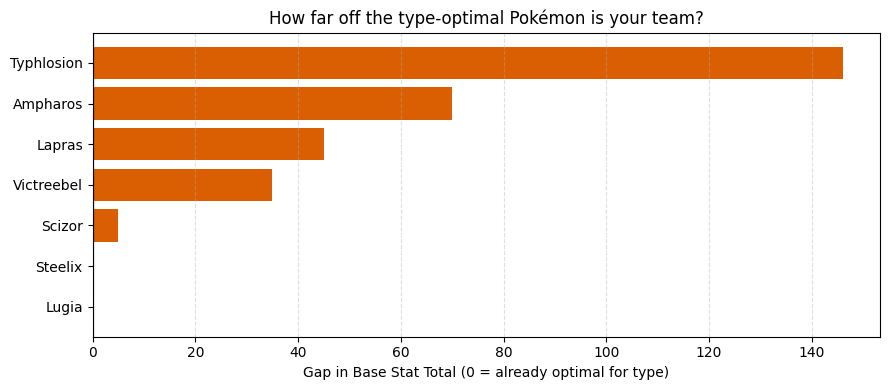

In [29]:
team_names = ", ".join(f"'{p}'" for p in MY_TEAM)

team = q(f"""
select pokemon_name, primary_type, secondary_type, base_stat_total
from main_intermediate.int_pokemon_stats
where pokemon_name in ({team_names})
""")

not_found = set(MY_TEAM) - set(team["pokemon_name"])
if not_found:
    print(f"⚠️  Not found in dataset: {not_found}")

# Best non-legendary per primary type within the active filter
best = q(f"""
select
    primary_type,
    max(base_stat_total)                   as best_base_stat_total,
    arg_max(pokemon_name, base_stat_total) as best_pokemon
from main_intermediate.int_pokemon_stats
where {BASE_FILTER}
group by primary_type
""")

analysis = (
    team
    .merge(best, on="primary_type", how="left")
    .assign(gap=lambda df: df["best_base_stat_total"] - df["base_stat_total"])
    [["pokemon_name", "primary_type", "secondary_type",
      "base_stat_total", "best_pokemon", "best_base_stat_total", "gap"]]
    .rename(columns={
        "pokemon_name":         "your_pokemon",
        "base_stat_total":      "your_bst",
        "best_base_stat_total": "best_bst",
    })
    .sort_values("gap", ascending=False)
    .reset_index(drop=True)
)

display(analysis)

# Bar chart of the gap
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#d95f02" if g > 0 else "#1b9e77" for g in analysis["gap"]]
ax.barh(analysis["your_pokemon"], analysis["gap"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.invert_yaxis()
ax.set_xlabel("Gap in Base Stat Total (0 = already optimal for type)")
ax.set_title("How far off the type-optimal Pokémon is your team?")
ax.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [33]:
upgrades_needed = analysis[analysis["gap"] > 20][["your_pokemon", "primary_type", "your_bst"]].reset_index(drop=True)

if upgrades_needed.empty:
    print("No Pokémon are more than 20 BST off the type optimal.")
else:
    for _, row in upgrades_needed.iterrows():
        alternatives = q(f"""
            select
                is_legendary,
                pokemon_name,
                secondary_type,
                base_stat_total
            from main_intermediate.int_pokemon_stats
            where {BASE_FILTER}
              and primary_type = '{row["primary_type"]}'
              and pokemon_name != '{row["your_pokemon"]}'
              and base_stat_total >= {row["your_bst"]}
            order by base_stat_total desc
        """)
        print(f"{row['your_pokemon']} ({row['primary_type']}) — alternatives with BST >= {row['your_bst']}:")
        display(alternatives.reset_index(drop=True))
        print()

Typhlosion (Fire) — alternatives with BST >= 534:


,is_legendary,pokemon_name,secondary_type,base_stat_total
0,True,Ho-oh,Flying,680
1,True,Moltres,Flying,580
2,True,Entei,None,580
3,False,Arcanine,None,555
4,False,Charizard,Flying,534



Ampharos (Electric) — alternatives with BST >= 510:


,is_legendary,pokemon_name,secondary_type,base_stat_total
0,True,Zapdos,Flying,580
1,True,Raikou,None,580
2,False,Jolteon,None,525



Lapras (Water) — alternatives with BST >= 535:


,is_legendary,pokemon_name,secondary_type,base_stat_total
0,True,Suicune,None,580
1,False,Gyarados,Flying,540
2,False,Kingdra,Dragon,540



Victreebel (Grass) — alternatives with BST >= 490:


,is_legendary,pokemon_name,secondary_type,base_stat_total
0,False,Venusaur,Poison,525
1,False,Meganium,None,525
2,False,Exeggutor,Psychic,520
3,False,Vileplume,Poison,490
4,False,Bellossom,None,490


In [34]:
covered_types = set(team["primary_type"])

uncovered = q(f"""
with ranked as (
    select
        primary_type,
        pokemon_name,
        secondary_type,
        is_legendary,
        base_stat_total,
        row_number() over (
            partition by primary_type
            order by base_stat_total desc
        ) as rn
    from main_intermediate.int_pokemon_stats
    where {BASE_FILTER}
      and primary_type not in ({", ".join(f"'{t}'" for t in covered_types)})
)
select primary_type, pokemon_name, secondary_type, is_legendary, base_stat_total
from ranked
where rn <= 3
order by primary_type, base_stat_total desc
""")

print(f"Types covered by your team: {', '.join(sorted(covered_types))}")
print(f"Uncovered types: {', '.join(sorted(uncovered['primary_type'].unique()))}\n")

for ptype in sorted(uncovered["primary_type"].unique()):
    print(f"{ptype}:")
    display(uncovered[uncovered["primary_type"] == ptype].drop(columns="primary_type").reset_index(drop=True))
    print()

Types covered by your team: Bug, Electric, Fire, Grass, Psychic, Steel, Water
Uncovered types: Dark, Dragon, Fairy, Fighting, Ghost, Ground, Ice, Normal, Poison, Rock

Dark:


,pokemon_name,secondary_type,is_legendary,base_stat_total
0,Umbreon,None,False,525
1,Houndoom,Fire,False,500
2,Sneasel,Ice,False,430



Dragon:


,pokemon_name,secondary_type,is_legendary,base_stat_total
0,Dragonite,Flying,False,600
1,Dragonair,None,False,420
2,Dratini,None,False,300



Fairy:


...

,pokemon_name,secondary_type,is_legendary,base_stat_total
0,Blissey,None,False,540
1,Snorlax,None,False,540
2,Porygon2,None,False,515



Poison:


,pokemon_name,secondary_type,is_legendary,base_stat_total
0,Crobat,Flying,False,535
1,Nidoking,Ground,False,505
2,Nidoqueen,Ground,False,505



Rock:


,pokemon_name,secondary_type,is_legendary,base_stat_total
0,Tyranitar,Dark,False,600
1,Aerodactyl,Flying,False,515
2,Kabutops,Water,False,495
